# **pipeline: Image brute => U-Net => masque binarisé => comptage stries => âge estimé**

**1. Installation**

In [1]:
!pip install segmentation-models-pytorch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 2.9 MB/s eta 0:00:00


**Imports**

In [2]:
import os, re
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from sklearn.model_selection import train_test_split
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Mapping**

In [ ]:
binarisee_dir = Path('/content/drive/MyDrive/unet_rapid')
brute_dir     = Path('/content/drive/MyDrive/2017')

records = []

for serialno_folder in sorted(binarisee_dir.iterdir()):
    if not serialno_folder.is_dir():
        continue
    serialno_str = serialno_folder.name  # ex: "70029"

    for otolithe_folder in sorted(serialno_folder.iterdir()):
        if not otolithe_folder.is_dir():
            continue

        folder_name = otolithe_folder.name          # ex: "Nr01_age04"
        nr_part = folder_name.split('_')[0]         # ex: "Nr01"
        age = int(folder_name.split('_age')[1])     # ex: 4

        img_bin_0   = otolithe_folder / 'image_0deg.png'
        img_bin_180 = otolithe_folder / 'image_180deg.png'

        if not img_bin_0.exists():
            continue

        # Chercher dans 2017/serialno/ un dossier commençant par nr_part
        brute_serialno = brute_dir / serialno_str
        if not brute_serialno.exists():
            continue

        # Cherche tous les dossiers dont le nom commence par nr_part (ex: "Nr01")
        matching = [d for d in brute_serialno.iterdir()
                    if d.is_dir() and d.name.upper().startswith(nr_part.upper())]

        if not matching:
            continue

        chemin_brut = matching[0]
        images_jpg = sorted(
            list(chemin_brut.glob('*.jpg')) +
            list(chemin_brut.glob('*.JPG'))
        )

        # Besoin d'au moins 1 image brute
        if len(images_jpg) == 0:
            continue

        # On prend la 1ère image pour 0° et la 4ème (si dispo) pour 180°
        img_brute_0   = str(images_jpg[0])
        img_brute_180 = str(images_jpg[3]) if len(images_jpg) >= 4 else str(images_jpg[-1])

        records.append({
            'serialno'       : int(serialno_str),
            'nr'             : nr_part,
            'age'            : age,
            'img_brute_0'    : img_brute_0,
            'img_brute_180'  : img_brute_180,
            'img_bin_0'      : str(img_bin_0),
            'img_bin_180'    : str(img_bin_180),
        })

df_mapping = pd.DataFrame(records)
print(f"✅ Paires trouvées : {len(df_mapping)}")
print(df_mapping.head())
df_mapping.to_csv('/content/drive/MyDrive/mapping_unet_rapid.csv', index=False)

✅ Paires trouvées : 479
   serialno    nr  age                                        img_brute_0  \
0     70029  Nr01    6  /content/drive/MyDrive/2017/70029/Nr01_age06/I...   
1     70029  Nr02    3  /content/drive/MyDrive/2017/70029/Nr02_age03/I...   
2     70029  Nr03    4  /content/drive/MyDrive/2017/70029/Nr03_age04/I...   
3     70029  Nr04    1  /content/drive/MyDrive/2017/70029/Nr04_age01/I...   
4     70029  Nr06    3  /content/drive/MyDrive/2017/70029/Nr06_age03/I...   

                                       img_brute_180  \
0  /content/drive/MyDrive/2017/70029/Nr01_age06/I...   
1  /content/drive/MyDrive/2017/70029/Nr02_age03/I...   
2  /content/drive/MyDrive/2017/70029/Nr03_age04/I...   
3  /content/drive/MyDrive/2017/70029/Nr04_age01/I...   
4  /content/drive/MyDrive/2017/70029/Nr06_age03/I...   

                                           img_bin_0  \
0  /content/drive/MyDrive/unet_rapid/70029/Nr01_a...   
1  /content/drive/MyDrive/unet_rapid/70029/Nr02_a...   
2  /cont

**Dataset avec augmentation légère**

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

def get_transforms(train=True):
    if train:
        return A.Compose([
            A.Rotate(limit=15, p=0.5),
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(p=0.3),
            A.GaussNoise(p=0.2),
            A.Resize(256, 256),
            ToTensorV2(),
        ])
    return A.Compose([A.Resize(256, 256), ToTensorV2()])


class OtolithDataset(Dataset):
    def __init__(self, df, train=True):
        self.df = df.reset_index(drop=True)
        self.train = train
        self.img_size = (256, 256)

    def __len__(self):
        return len(self.df) * 2

    def _load(self, path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.zeros(self.img_size, dtype=np.uint8)
        # Redimensionner ici
        img = cv2.resize(img, self.img_size)
        return img

    def __getitem__(self, idx):
        row_idx = idx // 2
        angle   = idx % 2
        row = self.df.iloc[row_idx]

        brute = self._load(row['img_brute_0']  if angle == 0 else row['img_brute_180'])
        mask  = self._load(row['img_bin_0']    if angle == 0 else row['img_bin_180'])

        # Les deux sont maintenant 256×256 => plus d'erreur de shape
        if self.train:
            aug = A.Compose([
                A.Rotate(limit=15, p=0.5),
                A.HorizontalFlip(p=0.5),
                A.RandomBrightnessContrast(p=0.3),
                A.GaussNoise(p=0.2),
            ])(image=brute, mask=mask)
            brute, mask = aug['image'], aug['mask']

        img_t  = torch.tensor(brute, dtype=torch.float32).unsqueeze(0) / 255.0
        mask_t = torch.tensor(mask,  dtype=torch.float32).unsqueeze(0) / 255.0

        age = torch.tensor(row['age'], dtype=torch.float32)
        return img_t, mask_t, age

**DataLoaders**

In [5]:
df_mapping = pd.read_csv('/content/drive/MyDrive/mapping_unet_rapid.csv')
print(f"Total paires : {len(df_mapping)}")

# Voir la distribution des âges
print("\nDistribution des âges :")
print(df_mapping['age'].value_counts().sort_index())

# Supprimer les âges avec moins de 2 exemples (impossibles à stratifier)
counts = df_mapping['age'].value_counts()
ages_ok = counts[counts >= 2].index
df_mapping = df_mapping[df_mapping['age'].isin(ages_ok)]
print(f"\nAprès filtrage : {len(df_mapping)} paires")

df_train, df_temp = train_test_split(df_mapping, test_size=0.30, random_state=42, stratify=df_mapping['age'])
df_val,   df_test = train_test_split(df_temp,    test_size=0.50, random_state=42)

print(f"Train: {len(df_train)*2} | Val: {len(df_val)*2} | Test: {len(df_test)*2}")

train_ds = OtolithDataset(df_train, train=True)
val_ds   = OtolithDataset(df_val,   train=False)
test_ds  = OtolithDataset(df_test,  train=False)

train_loader = DataLoader(train_ds, batch_size=8,  shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=8,  shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=8,  shuffle=False, num_workers=2, pin_memory=True)
print("✅ DataLoaders prêts")

Total paires : 479

Distribution des âges :
age
0      1
1     10
2     14
3     28
4     29
5     42
6     64
7     57
8     71
9     50
10    30
11    30
12    34
13    10
14     5
15     2
16     2
Name: count, dtype: int64

Après filtrage : 478 paires
Train: 668 | Val: 144 | Test: 144
✅ DataLoaders prêts


**Modèle + Loss combinée**

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

# U-Net léger avec ResNet18 (rapide + efficace pour Colab)
model = smp.Unet(
    encoder_name    = 'resnet18',      # léger, rapide
    encoder_weights = 'imagenet',      # transfer learning
    in_channels     = 1,               # grayscale
    classes         = 1,
    activation      = None,
).to(device)

# Loss combinée BCE + Dice (meilleure pour segmentation de stries fines)
bce_loss  = nn.BCEWithLogitsLoss()
dice_loss = smp.losses.DiceLoss(mode='binary', from_logits=True)

def combined_loss(pred, target):
    return 0.5 * bce_loss(pred, target) + 0.5 * dice_loss(pred, target)

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

print(f"Paramètres : {sum(p.numel() for p in model.parameters()):,}")

Device : cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Paramètres : 14,321,937


**Entraînement avec EarlyStopping**

In [ ]:
def iou_score(pred, target, threshold=0.5):
    pred_bin = (torch.sigmoid(pred) > threshold).float()
    inter = (pred_bin * target).sum()
    union = pred_bin.sum() + target.sum() - inter
    return (inter / (union + 1e-6)).item()


def train_epoch(model, loader, optimizer):
    model.train()
    total_loss, total_iou = 0, 0
    for imgs, masks, _ in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = combined_loss(preds, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_iou  += iou_score(preds, masks)
    n = len(loader)
    return total_loss / n, total_iou / n


@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    total_loss, total_iou = 0, 0
    for imgs, masks, _ in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        total_loss += combined_loss(preds, masks).item()
        total_iou  += iou_score(preds, masks)
    n = len(loader)
    return total_loss / n, total_iou / n


# *** Boucle d'entraînement ************************************************
EPOCHS    = 50
PATIENCE  = 10
best_val_loss = float('inf')
patience_ctr  = 0
history = {'train_loss': [], 'val_loss': [], 'train_iou': [], 'val_iou': []}

CKPT = '/content/drive/MyDrive/best_unet_otolith.pth'

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_iou = train_epoch(model, train_loader, optimizer)
    vl_loss, vl_iou = eval_epoch(model, val_loader)
    scheduler.step(vl_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_iou'].append(tr_iou)
    history['val_iou'].append(vl_iou)

    print(f"Ep {epoch:03d} | train loss={tr_loss:.4f} iou={tr_iou:.3f} | "
          f"val loss={vl_loss:.4f} iou={vl_iou:.3f}")

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        patience_ctr  = 0
        torch.save(model.state_dict(), CKPT)
        print(f"  ✅ Meilleur modèle sauvegardé (val_loss={best_val_loss:.4f})")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"⏹ Early stopping à l'époque {epoch}")
            break

print("Entraînement terminé !")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Ep 001 | train loss=0.4333 iou=0.340 | val loss=0.3149 iou=0.377
  ✅ Meilleur modèle sauvegardé (val_loss=0.3149)
Ep 002 | train loss=0.2982 iou=0.360 | val loss=0.2589 iou=0.361
  ✅ Meilleur modèle sauvegardé (val_loss=0.2589)
Ep 003 | train loss=0.2633 iou=0.349 | val loss=0.2289 iou=0.358
  ✅ Meilleur modèle sauvegardé (val_loss=0.2289)
Ep 004 | train loss=0.2475 iou=0.345 | val loss=0.2199 iou=0.346
  ✅ Meilleur modèle sauvegardé (val_loss=0.2199)
Ep 005 | train loss=0.2413 iou=0.342 | val loss=0.2185 iou=0.344
  ✅ Meilleur modèle sauvegardé (val_loss=0.2185)
Ep 006 | train loss=0.2375 iou=0.342 | val loss=0.2176 iou=0.346
  ✅ Meilleur modèle sauvegardé (val_loss=0.2176)
Ep 007 | train loss=0.2367 iou=0.340 | val loss=0.2165 iou=0.352
  ✅ Meilleur modèle sauvegardé (val_loss=0.2165)
Ep 008 | train loss=0.2357 iou=0.339 | val loss=0.2112 iou=0.337
  ✅ Meilleur modèle sauvegardé (val_loss=0.2112)
Ep 009 | train loss=0.2331 iou=0.340 | val loss=0.2138 iou=0.343
Ep 010 | train loss=0.2

**Courbes d'apprentissage**

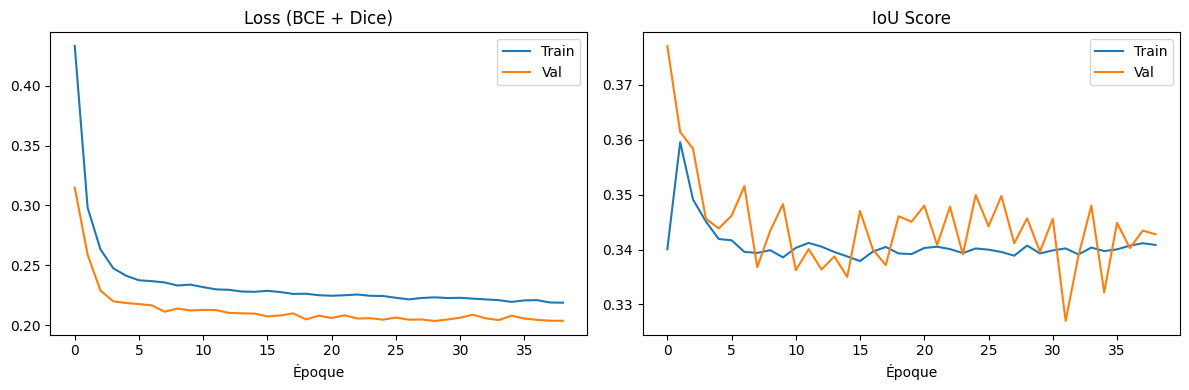

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'],   label='Val')
ax1.set_title('Loss (BCE + Dice)')
ax1.set_xlabel('Époque'); ax1.legend()

ax2.plot(history['train_iou'], label='Train')
ax2.plot(history['val_iou'],   label='Val')
ax2.set_title('IoU Score')
ax2.set_xlabel('Époque'); ax2.legend()
plt.tight_layout(); plt.show()

**Évaluation + comptage de stries → âge**


📊 Résultats sur le test set :
   MAE âge estimé vs vrai : 4.74 ans


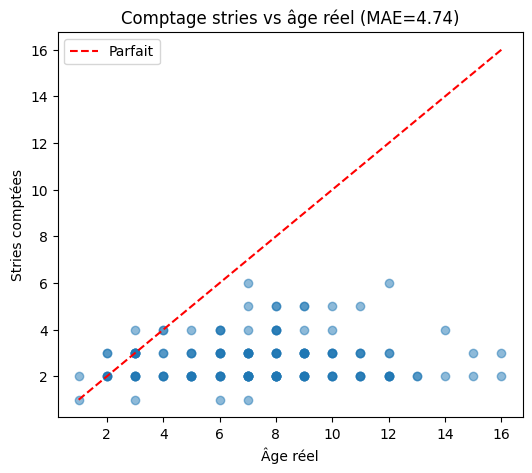

In [ ]:
def count_stries(mask_np, threshold=0.5):
    """
    Compte les anneaux (stries) dans le masque prédit.
    Stratégie : projection radiale + détection de pics.
    """
    from scipy.signal import find_peaks
    binary = (mask_np > threshold).astype(np.uint8) * 255
    h, w = binary.shape
    cx, cy = w // 2, h // 2
    # Projection horizontale centrée
    strip = binary[cy-5:cy+5, :]
    profile = strip.mean(axis=0)
    peaks, _ = find_peaks(profile, distance=5, prominence=10)
    return len(peaks)


# Charger le meilleur modele
model.load_state_dict(torch.load(CKPT, map_location=device))
model.eval()

errors, true_ages, pred_counts = [], [], []

with torch.no_grad():
    for imgs, masks, ages in test_loader:
        imgs = imgs.to(device)
        preds = torch.sigmoid(model(imgs)).cpu().numpy()  # (B,1,256,256)
        for i in range(len(ages)):
            mask_pred = preds[i, 0]
            n_stries  = count_stries(mask_pred)
            true_age  = int(ages[i].item())
            true_ages.append(true_age)
            pred_counts.append(n_stries)
            errors.append(abs(n_stries - true_age))

mae = np.mean(errors)
print(f"\n📊 Résultats sur le test set :")
print(f"   MAE âge estimé vs vrai : {mae:.2f} ans")

# Scatter vrai âge vs stries comptées
plt.figure(figsize=(6, 5))
plt.scatter(true_ages, pred_counts, alpha=0.5)
plt.plot([min(true_ages), max(true_ages)],
         [min(true_ages), max(true_ages)], 'r--', label='Parfait')
plt.xlabel('Âge réel'); plt.ylabel('Stries comptées')
plt.title(f'Comptage stries vs âge réel (MAE={mae:.2f})')
plt.legend(); plt.show()

**Visualisation qualitative**

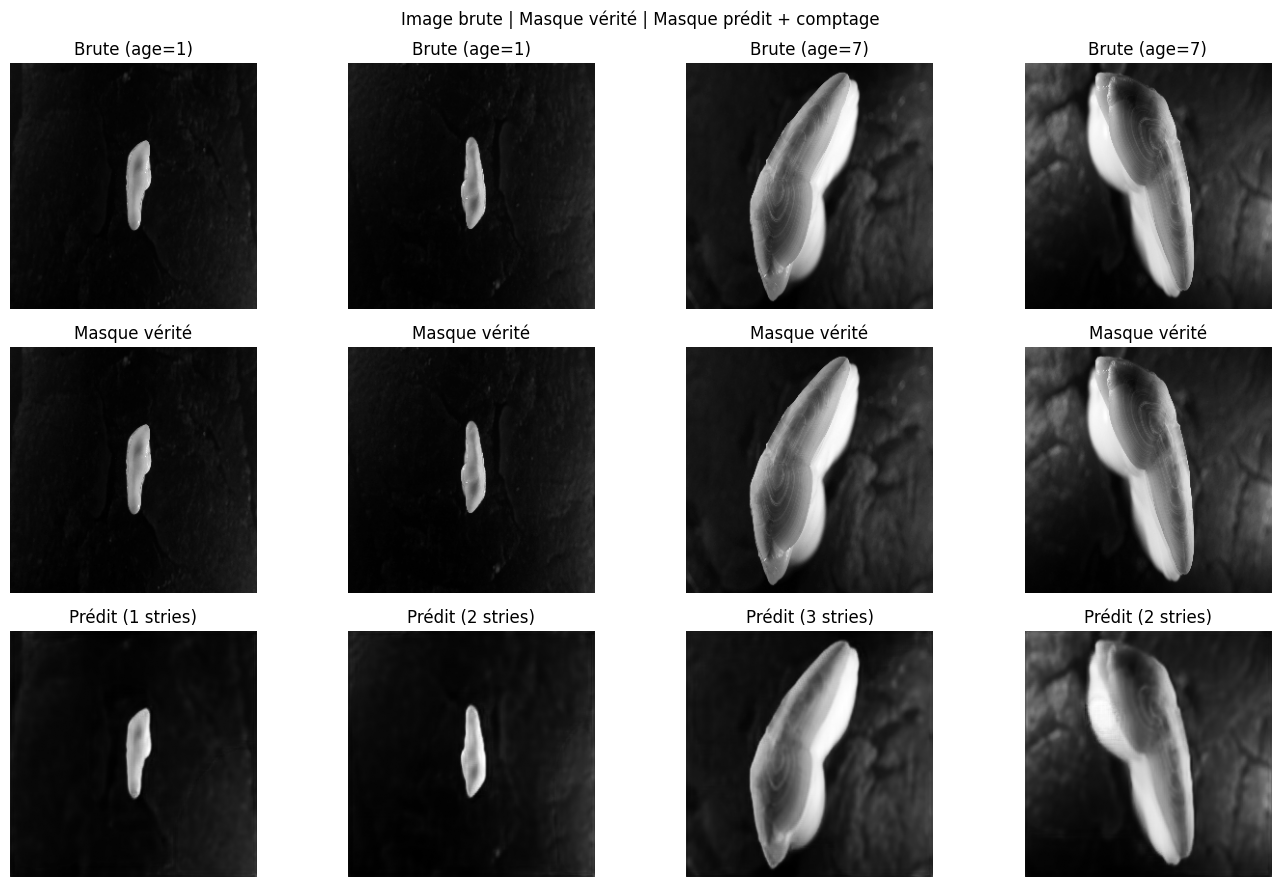

In [10]:
model.eval()
imgs_batch, masks_batch, ages_batch = next(iter(test_loader))
imgs_batch = imgs_batch.to(device)

with torch.no_grad():
    preds_batch = torch.sigmoid(model(imgs_batch)).cpu()

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
for i in range(4):
    axes[0, i].imshow(imgs_batch[i, 0].cpu(), cmap='gray')
    axes[0, i].set_title(f'Brute (age={int(ages_batch[i])})')
    axes[0, i].axis('off')

    axes[1, i].imshow(masks_batch[i, 0], cmap='gray')
    axes[1, i].set_title('Masque vérité')
    axes[1, i].axis('off')

    pred_np = preds_batch[i, 0].numpy()
    n = count_stries(pred_np)
    axes[2, i].imshow(pred_np, cmap='gray')
    axes[2, i].set_title(f'Prédit ({n} stries)')
    axes[2, i].axis('off')

plt.suptitle('Image brute | Masque vérité | Masque prédit + comptage')
plt.tight_layout(); plt.show()

**Amélioration du comptage des stries**

In [12]:
def count_stries(mask_np, threshold=0.5):
    """
    Comptage par projection radiale depuis le centre de l'otolithe.
    Bien plus robuste que la projection horizontale.
    """
    from scipy.signal import find_peaks, savgol_filter

    binary = (mask_np > threshold).astype(np.float32)
    h, w = binary.shape
    cx, cy = w // 2, h // 2

    # Profil radial : moyenne sur 360 rayons
    n_angles = 360
    max_r    = min(cx, cy) - 5
    profile  = np.zeros(max_r)

    for r in range(1, max_r):
        vals = []
        for a in range(n_angles):
            ang = 2 * np.pi * a / n_angles
            x = int(cx + r * np.cos(ang))
            y = int(cy + r * np.sin(ang))
            if 0 <= x < w and 0 <= y < h:
                vals.append(binary[y, x])
        if vals:
            profile[r] = np.mean(vals)

    # Lissage + détection de pics
    if len(profile) > 7:
        profile = savgol_filter(profile, window_length=7, polyorder=2)

    peaks, props = find_peaks(
        profile,
        distance   = 4,
        prominence = 0.05,
        height     = 0.1
    )
    return len(peaks)

**verif**

In [13]:
# IoU moyen sur le test set (qualité pure du U-Net)
model.load_state_dict(torch.load(CKPT, map_location=device))
model.eval()

ious = []
with torch.no_grad():
    for imgs, masks, _ in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        ious.append(iou_score(preds, masks))

print(f"IoU moyen test : {np.mean(ious):.3f}")

IoU moyen test : 0.337


**Métriques de segmentation complètes**

In [14]:
from sklearn.metrics import jaccard_score, f1_score, precision_score, recall_score

model.load_state_dict(torch.load(CKPT, map_location=device))
model.eval()

all_preds, all_masks = [], []

with torch.no_grad():
    for imgs, masks, _ in test_loader:
        imgs = imgs.to(device)
        preds = torch.sigmoid(model(imgs)).cpu()
        preds_bin = (preds > 0.5).float()
        all_preds.append(preds_bin.view(-1).numpy())
        all_masks.append(masks.view(-1).numpy())

all_preds = np.concatenate(all_preds).astype(int)
all_masks = np.concatenate(all_masks).astype(int)

iou       = jaccard_score(all_masks, all_preds, zero_division=0)
dice      = f1_score(all_masks, all_preds, zero_division=0)
precision = precision_score(all_masks, all_preds, zero_division=0)
recall    = recall_score(all_masks, all_preds, zero_division=0)

print("=" * 40)
print("  MÉTRIQUES DE SEGMENTATION (Test set)")
print("=" * 40)
print(f"  IoU (Jaccard)  : {iou:.4f}")
print(f"  Dice (F1)      : {dice:.4f}")
print(f"  Précision      : {precision:.4f}")
print(f"  Rappel         : {recall:.4f}")
print("=" * 40)

  MÉTRIQUES DE SEGMENTATION (Test set)
  IoU (Jaccard)  : 0.0002
  Dice (F1)      : 0.0003
  Précision      : 0.0002
  Rappel         : 0.9563


**Analyse âge : vrai vs estimé**

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  ESTIMATION D'ÂGE (Test set)
  MAE  : 5.54 ans
  RMSE : 6.39 ans
  r de Pearson : 0.195  (p=0.0190)


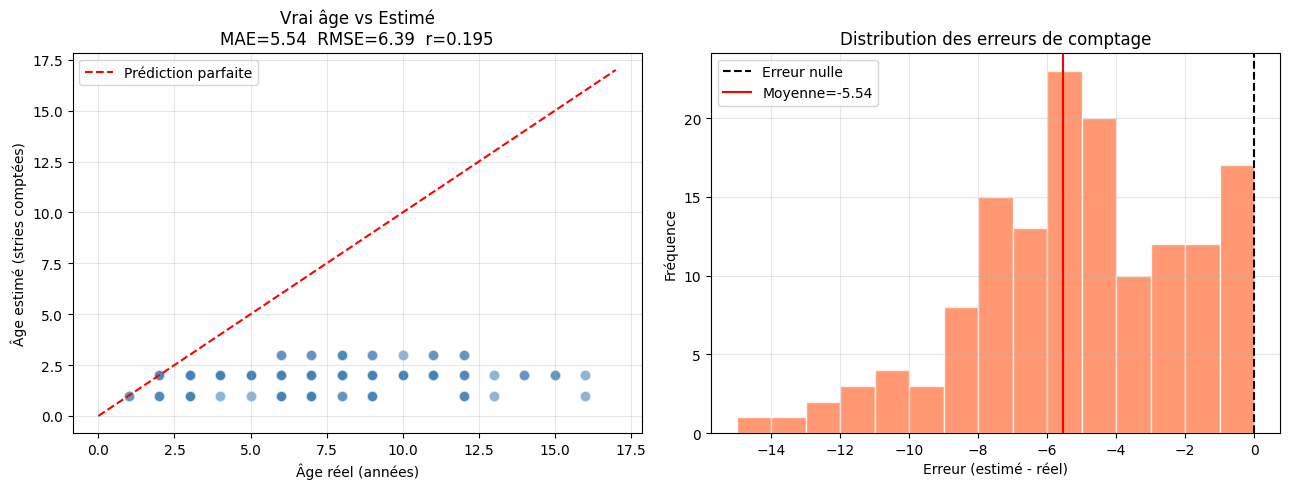

In [16]:
from scipy.stats import pearsonr

true_ages, pred_ages, sample_ious = [], [], []

model.eval()
with torch.no_grad():
    for imgs, masks, ages in test_loader:
        imgs_d = imgs.to(device)
        preds  = torch.sigmoid(model(imgs_d)).cpu().numpy()
        for i in range(len(ages)):
            n      = count_stries(preds[i, 0])
            true_a = int(ages[i].item())
            true_ages.append(true_a)
            pred_ages.append(n)

true_ages = np.array(true_ages)
pred_ages = np.array(pred_ages)
mae       = np.mean(np.abs(true_ages - pred_ages))
rmse      = np.sqrt(np.mean((true_ages - pred_ages) ** 2))
r, pval   = pearsonr(true_ages, pred_ages)

print("=" * 40)
print("  ESTIMATION D'ÂGE (Test set)")
print("=" * 40)
print(f"  MAE  : {mae:.2f} ans")
print(f"  RMSE : {rmse:.2f} ans")
print(f"  r de Pearson : {r:.3f}  (p={pval:.4f})")
print("=" * 40)

# Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(true_ages, pred_ages, alpha=0.6, color='steelblue', edgecolors='white', s=60)
lim = [min(true_ages.min(), pred_ages.min()) - 1,
       max(true_ages.max(), pred_ages.max()) + 1]
axes[0].plot(lim, lim, 'r--', label='Prédiction parfaite')
axes[0].set_xlabel('Âge réel (années)')
axes[0].set_ylabel('Âge estimé (stries comptées)')
axes[0].set_title(f'Vrai âge vs Estimé\nMAE={mae:.2f}  RMSE={rmse:.2f}  r={r:.3f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Distribution des erreurs
errors = pred_ages - true_ages
axes[1].hist(errors, bins=15, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', label='Erreur nulle')
axes[1].axvline(errors.mean(), color='red', linestyle='-',
                label=f'Moyenne={errors.mean():.2f}')
axes[1].set_xlabel('Erreur (estimé - réel)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des erreurs de comptage')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/analyse_age.png', dpi=150)
plt.show()

**Erreur par classe d'âge**

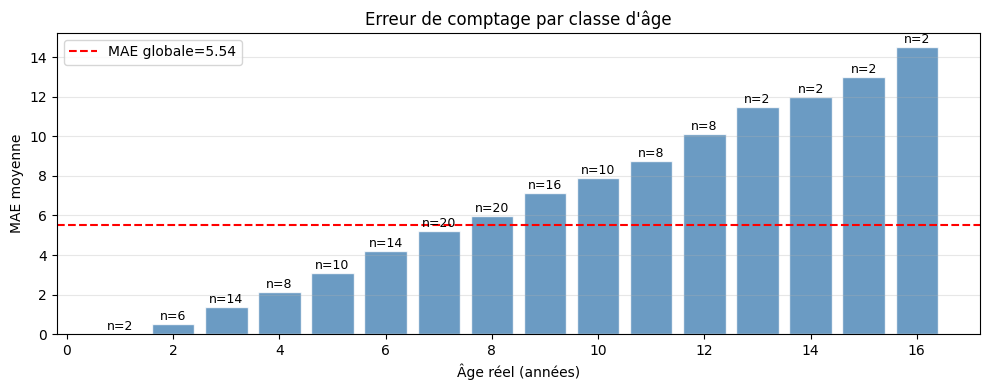

In [ ]:
df_results = pd.DataFrame({'age_reel': true_ages, 'age_predit': pred_ages})
df_results['erreur_abs'] = np.abs(df_results['age_reel'] - df_results['age_predit'])

mae_par_age = df_results.groupby('age_reel')['erreur_abs'].agg(['mean', 'count'])

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(mae_par_age.index, mae_par_age['mean'],
              color='steelblue', alpha=0.8, edgecolor='white')

# Annoter avec le nombre d'expl
for bar, (age, row) in zip(bars, mae_par_age.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'n={int(row["count"])}', ha='center', va='bottom', fontsize=9)

ax.axhline(mae, color='red', linestyle='--', label=f'MAE globale={mae:.2f}')
ax.set_xlabel('Âge réel (années)')
ax.set_ylabel('MAE moyenne')
ax.set_title('Erreur de comptage par classe d\'âge')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/mae_par_age.png', dpi=150)
plt.show()

**Matrice de confusion âge**

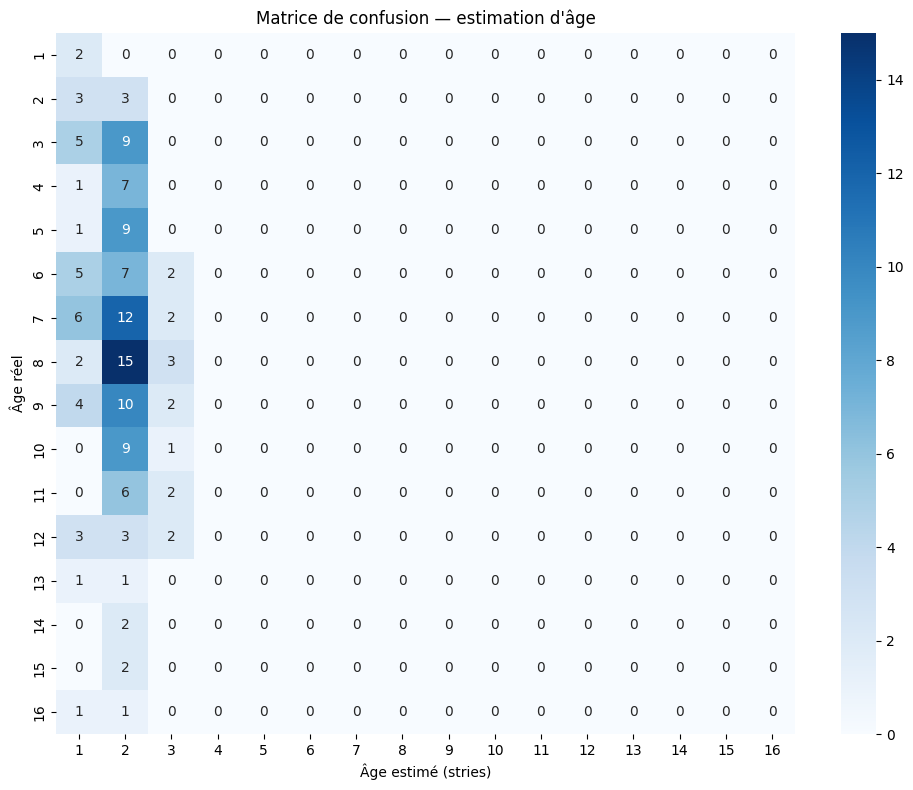

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

ages_uniques = sorted(set(true_ages) | set(pred_ages))
cm = confusion_matrix(true_ages, pred_ages, labels=ages_uniques)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ages_uniques, yticklabels=ages_uniques)
plt.xlabel('Âge estimé (stries)')
plt.ylabel('Âge réel')
plt.title('Matrice de confusion — estimation d\'âge')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/matrice_confusion_age.png', dpi=150)
plt.show()